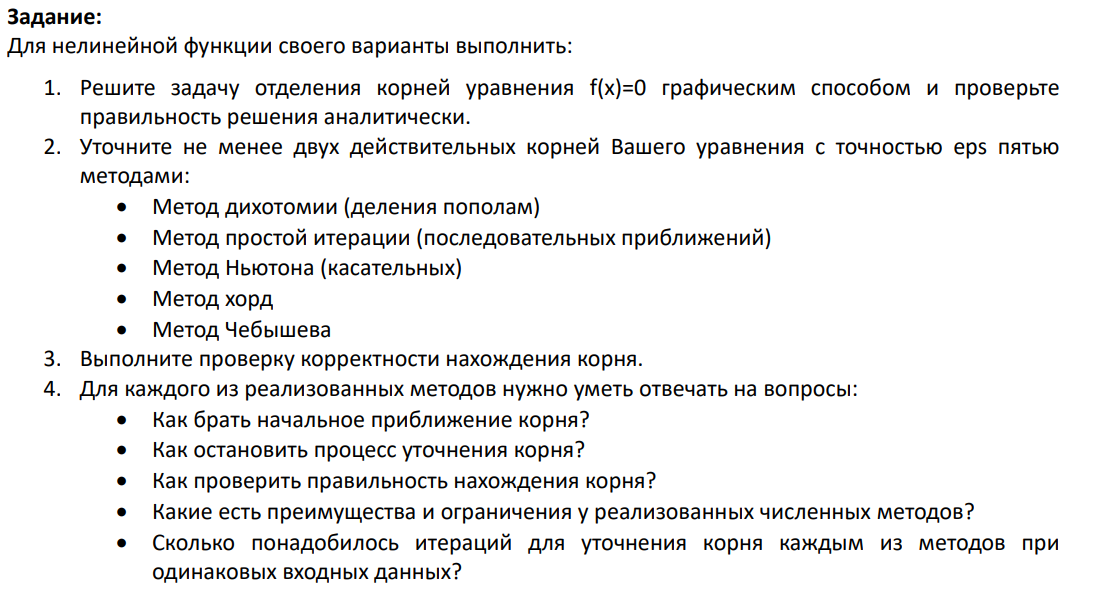
### Вариант 16
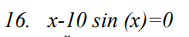

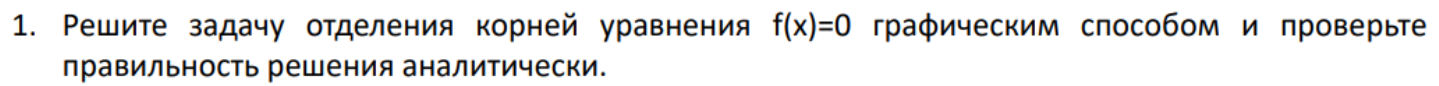

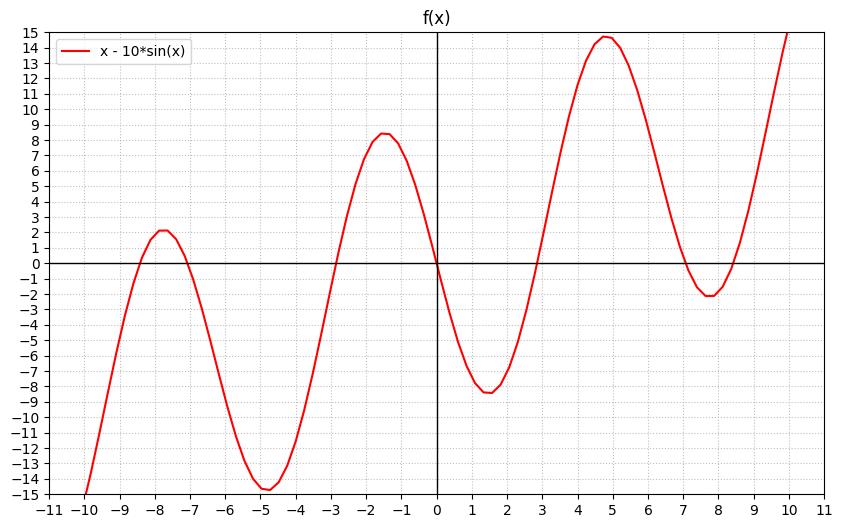

In [85]:
from matplotlib.ticker import MultipleLocator
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return x - 10 * np.sin(x)


def df(x):
    return 1 - 10 * np.cos(x)

    
def ddf(x):
    return 10 * np.sin(x)


x = np.linspace(-12,12,100)
y = f(x)

plt.figure(figsize=(10,6))

plt.plot(x,y,color="red",label='x - 10*sin(x)')

plt.axhline(0,color='black',linewidth=1)
plt.axvline(0,color='black',linewidth=1)
plt.grid(True,linestyle=':',alpha=0.8)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))

plt.xlim(-11,11)
plt.ylim(-15,15)
plt.title("f(x)")
plt.legend()
plt.show()


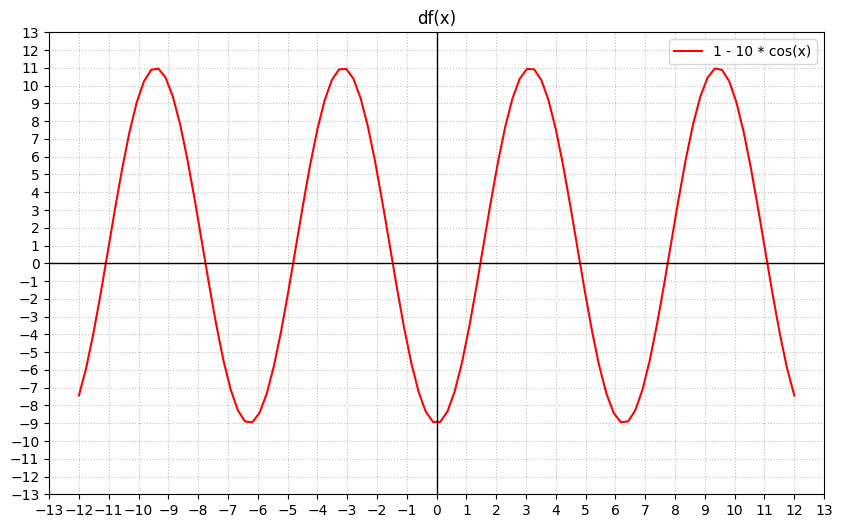

In [86]:
dy = df(x)

plt.figure(figsize=(10,6))

plt.plot(x,dy,color="red",label='1 - 10 * cos(x)')

plt.axhline(0,color='black',linewidth=1)
plt.axvline(0,color='black',linewidth=1)
plt.grid(True,linestyle=':',alpha=0.8)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))

plt.xlim(-13,13)
plt.ylim(-13,13)
plt.title("df(x)")
plt.legend()
plt.show()

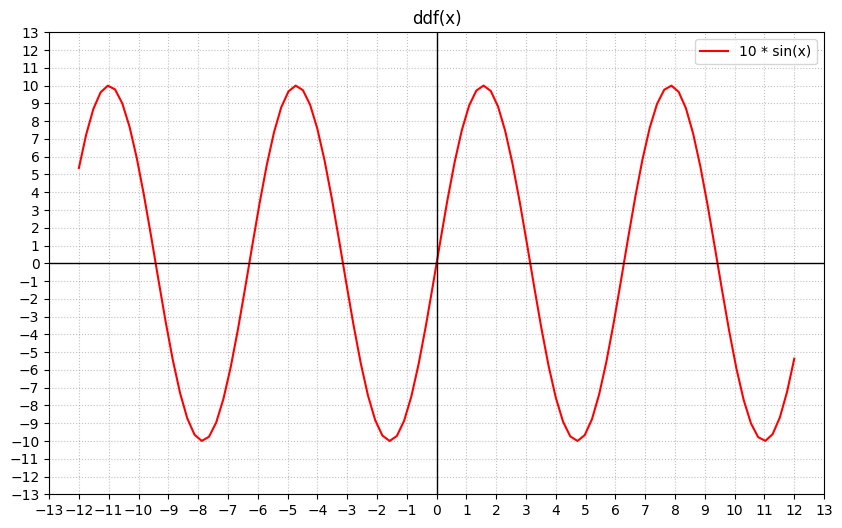

In [87]:
ddy = ddf(x)

plt.figure(figsize=(10,6))

plt.plot(x,ddy,color="red",label='10 * sin(x)')

plt.axhline(0,color='black',linewidth=1)
plt.axvline(0,color='black',linewidth=1)
plt.grid(True,linestyle=':',alpha=0.8)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(1))

plt.xlim(-13,13)
plt.ylim(-13,13)
plt.title("ddf(x)")
plt.legend()
plt.show()

In [88]:
intervals = []
for i in range(len(x) - 1):
    if y[i] * y[i+1] < 0:
        intervals.append((x[i], x[i+1]))
    elif y[i] == 0:
        intervals.append((x[i], x[i]))

print("Интервалы смены знака f(x) (содержат корни) | Значения в корнях      |     т.Больцано-Коши        |        Производная в точках")
for (x1, x2) in intervals:
    print(f"[{x1:.6f}, {x2:.6f}] \
        f({x1:.3f})={f(x1):.3f}, f({x2:.3f})={f(x2):.3f} \
        f({x1:.3f})*f({x2:.3f})={(f(x1)*f(x2)):.3f} \
        df({x1:.3f})={df(x1):.3f} df({x2:.3f})={df(x2):.3f} ")
    

Интервалы смены знака f(x) (содержат корни) | Значения в корнях      |     т.Больцано-Коши        |        Производная в точках
[-8.606061, -8.363636]         f(-8.606)=-1.303, f(-8.364)=0.365         f(-8.606)*f(-8.364)=-0.476         df(-8.606)=7.832 df(-8.364)=5.879 
[-7.151515, -6.909091]         f(-7.152)=0.481, f(-6.909)=-1.051         f(-7.152)*f(-6.909)=-0.505         df(-7.152)=-5.461 df(-6.909)=-7.104 
[-3.030303, -2.787879]         f(-3.030)=-1.920, f(-2.788)=0.676         f(-3.030)*f(-2.788)=-1.298         df(-3.030)=10.938 df(-2.788)=10.381 
[-0.121212, 0.121212]         f(-0.121)=1.088, f(0.121)=-1.088         f(-0.121)*f(0.121)=-1.184         df(-0.121)=-8.927 df(0.121)=-8.927 
[2.787879, 3.030303]         f(2.788)=-0.676, f(3.030)=1.920         f(2.788)*f(3.030)=-1.298         df(2.788)=10.381 df(3.030)=10.938 
[6.909091, 7.151515]         f(6.909)=1.051, f(7.152)=-0.481         f(6.909)*f(7.152)=-0.505         df(6.909)=-7.104 df(7.152)=-5.461 
[8.363636, 8.606061]    

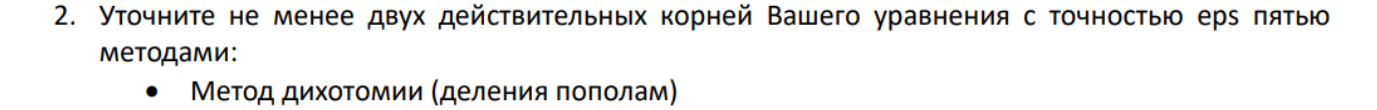

In [89]:
eps = 1e-5
max_iter = 10001

def dihtomii(a,b):
    """Метод деления пополам"""
    
    fa = f(a)
    fb = f(b)
    if fa * fb > 0:
        raise ValueError("Знаки не противоположны")

    iters = []
    
    for i in range(max_iter):
        c = (a+b)/2
        fc = f(c)
        iters.append((i,a,b,c,fc))
        
        if (b-a) / 2 < eps:
            return c, i 
        
        # корень в левой половине
        if fa * fc < 0:
            b = c
            fb = fc
        # корень в правой половине  
        else:
            a = c
            fa = fc
            
    return c, iters

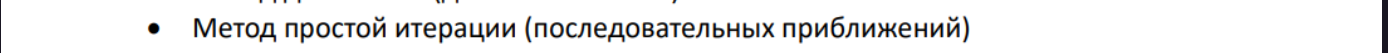

In [90]:
def simple_iters(f,x0,lam):
    """x = фи(x)"""
    phi = lambda x: x - lam * f(x)
    x_prev = x0
    iters = [x_prev]
    
    for i in range(max_iter):
        x_next = phi(x_prev)
        iters.append(x_next)
        
        if abs(x_next - x_prev) < eps:
            return x_next, i+1
        
        x_prev = x_next
    
    return x_next, iters


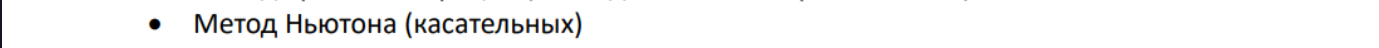

In [91]:
def newton(x0):
    """Метод Ньютона"""
    iters = 0
    x = x0
    
    for _ in range(max_iter):
        der = df(x)
        if abs(der) < 1e-12: break
        x_new = x - f(x) / der
        if abs(x_new - x) < eps:
            return x_new, iters + 1
        x = x_new
        iters += 1
        
    return x_new, iters

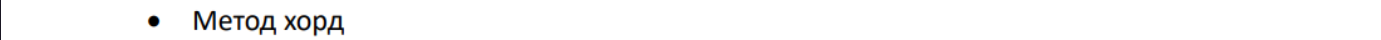

In [92]:
def chord(a,b):
    iters = 0
        
    if f(a) * ddf(a) > 0:
        fixed = a
        moving = b
    else:
        fixed = b
        moving = a

        
    for _ in range(max_iter):
        ffix = f(fixed)
        fmov = f(moving)
        
        c = (fixed * fmov - moving * ffix) / (fmov - ffix)
        
        if abs(f(c)) < eps:
            return c, iters + 1
        
        moving = c
        iters += 1

    return c, iters
        

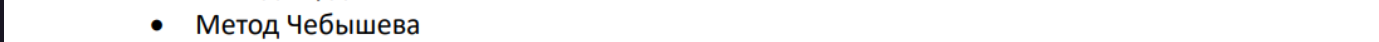

In [93]:
def chebyshev(x0):
    iters = 0
    x = x0
    
    for _ in range(max_iter):
        fx = f(x)
        dfx = df(x)
        ddfx = ddf(x)
        
        x_new = x - (fx/dfx) - (0.5 * ddfx * ((fx/dfx)**2) / dfx)
        
        if abs(x_new - x) < eps:
            return x_new, iters + 1
        
        x = x_new
        iters += 1
        
    return x_new, iters
        

In [96]:
if __name__ == "__main__":
    
    # Интервал 1 - [2.787879, 3.030303]
    print("Корень 1 на интервале [2.787879, 3.030303]\n")
    x0, x1 = 2.787879, 3.030303
    
    r1_dihtomii, i1_1 = dihtomii(x0,x1)
    print(f"Дихтомия: {r1_dihtomii} итерация: {i1_1} точность: {f(r1_dihtomii)}") 
    
    # df(x1)>0 => лямбда > 0 => 
    lam_1 = 1/df(x0)
    f = lambda x : x - 10*np.sin(x)
    
    r1_simple, i2_1 = simple_iters(f,x1,lam_1)
    print(f"Простая итерация: {r1_simple} итерация: {i2_1} точность: {f(r1_simple)}")
    
    r1_newton, i3_1 = newton(x0)
    print(f"Ньютона: {r1_newton} итерация: {i3_1} точность: {f(r1_newton)}")
    
    r1_chord, i4_1 = chord(x0,x1)
    print(f"Хорд: {r1_chord} итерация: {i4_1} точность: {f(r1_chord)}")
    
    r1_chebyshev, i5_1 = chebyshev(x0)
    print(f"Чебышев: {r1_chebyshev} итерация: {i5_1} точность: {f(r1_chebyshev)}")
   
   
    # Интервал 2 - [6.909091, 7.151515]    
    print("\nКорень 2 на интервале [6.909091, 7.151515]\n")
    x0, x1 = 6.909091, 7.151515
    
    r2_dihtomii, i1_2 = dihtomii(x0,x1)
    print(f"Дихтомия: {r2_dihtomii} итерация: {i1_2} точность: {f(r2_dihtomii)}") 
    
    # df(x1)<0 => лямбда < 0 => 
    lam_2 = 1/df(x0)
    
    r2_simple, i2_2 = simple_iters(f,x1,lam_2)
    print(f"Простая итерация: {r2_simple} итерация: {i2_2} точность: {f(r2_simple)}")
    
    r2_newton, i3_2 = newton(x0)
    print(f"Ньютона: {r2_newton} итерация: {i3_2} точность: {f(r2_newton)}")
    
    r2_chord, i4_2 = chord(x0,x1)
    print(f"Хорд: {r2_chord} итерация: {i4_2} точность: {f(r2_chord)}")
    
    r2_chebyshev, i5_2 = chebyshev(x0)
    print(f"Чебышев: {r2_chebyshev} итерация: {i5_2} {f(r2_chebyshev)}")


Корень 1 на интервале [2.787879, 3.030303]

Дихтомия: 2.852339458740234 итерация: 14 точность: -2.5780953818888008e-05
Простая итерация: 2.8523419444938463 итерация: 4 точность: 5.296920546626893e-07
Ньютона: 2.8523418944500922 итерация: 3 точность: 6.217248937900877e-15
Хорд: 2.852341423856904 итерация: 3 точность: -4.9810302393815675e-06
Чебышев: 2.852341894450092 итерация: 3 точность: 1.3322676295501878e-15

Корень 2 на интервале [6.909091, 7.151515]

Дихтомия: 7.06817435180664 итерация: 14 точность: 3.820021454714606e-08
Простая итерация: 7.068175425782857 итерация: 6 точность: -6.485084430352117e-06
Ньютона: 7.068174358095818 итерация: 4 точность: -2.6645352591003757e-15
Хорд: 7.0681746621187695 итерация: 5 точность: -1.8466229487756891e-06
Чебышев: 7.068174358095817 итерация: 3 2.6645352591003757e-15


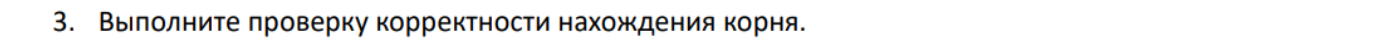

In [95]:
print(f(r1_newton))
print(f(r1_dihtomii))
print(f(r1_chebyshev))
print(f(r1_chord))
print(f(r1_simple))

print(f"\n{f(r2_newton)}")
print(f(r2_dihtomii))
print(f(r2_chebyshev))
print(f(r2_chord))
print(f(r2_simple))

6.217248937900877e-15
-2.5780953818888008e-05
1.3322676295501878e-15
-4.9810302393815675e-06
5.296920546626893e-07

-2.6645352591003757e-15
3.820021454714606e-08
2.6645352591003757e-15
-1.8466229487756891e-06
-6.485084430352117e-06


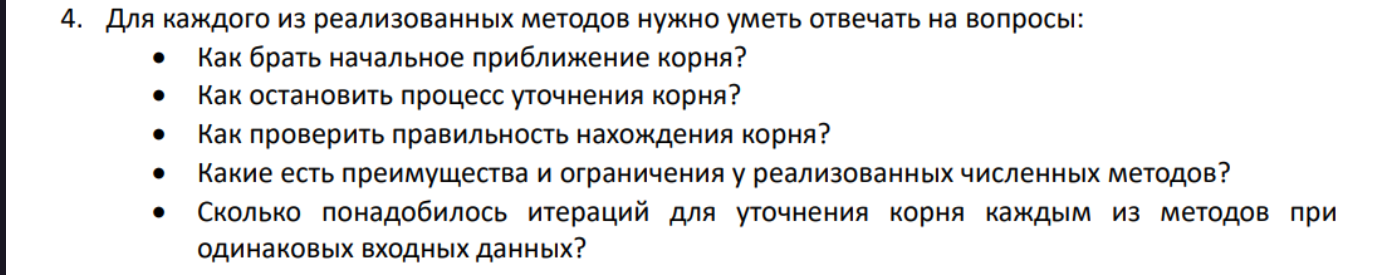

## Преумущества
### Дихотомии
Гарантированная сходимость при f(a)*f(b)<0
Не нужна производная

### Простой итерации
легкая реализация
можно управлять скоростью сходимости за счёт лямбды

### Ньютона
Быстрая сходимость при хорошем начальном приближении

### Хорд
не требует производной
быстрее дихотомии

### Чебышева
очень быстрый при хорошем x0


## Недостатки
### Дихотомии
Медленная сходимость
Нужен отрезок с разными знаками на концах

### Простой итерации
нужен правильный подбор лямбды 

### Ньютона
требуется вычисление производной
может раходиться при плохом x0

### Хорд
чуть медленнее ньютона

### Чебышева
требуются первая и вторая производные
чувствителен к x0
